In [58]:
import pandas as pd


data = pd.read_csv("/kaggle/input/datasets/semalkulathilaka/chernobyldisaster/cancer_before_and_after_Chernobyl.csv")
print("shape",data.shape)
print(data.info())
print(data.isnull().sum())


shape (84, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         84 non-null     int64  
 1   sex          84 non-null     object 
 2   location     84 non-null     object 
 3   cancer_type  84 non-null     object 
 4   cases        84 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 3.4+ KB
None
year           0
sex            0
location       0
cancer_type    0
cases          0
dtype: int64


In [59]:
print(data.describe())              
print(data.describe(include=['O']))



              year      cases
count    84.000000  84.000000
mean   1985.500000  10.688095
std       0.503003  13.924031
min    1985.000000   0.500000
25%    1985.000000   3.500000
50%    1985.500000   6.350000
75%    1986.000000  10.275000
max    1986.000000  73.100000
          sex location cancer_type
count      84       84          84
unique      2        3           7
top     women    Gomel        skin
freq       42       28          12


In [60]:
print(data.describe())   

              year      cases
count    84.000000  84.000000
mean   1985.500000  10.688095
std       0.503003  13.924031
min    1985.000000   0.500000
25%    1985.000000   3.500000
50%    1985.500000   6.350000
75%    1986.000000  10.275000
max    1986.000000  73.100000


Duplicate rows: 0


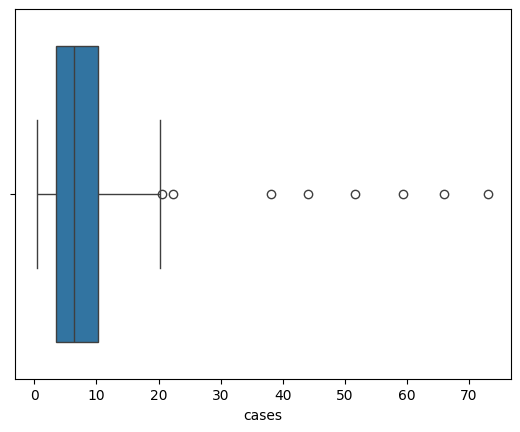

In [61]:

print("Duplicate rows:", data.duplicated().sum())


import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=data["cases"])         
plt.show()


In [62]:
data['sex'] = data['sex'].map({'men': 0, 'women': 1})
data.head()


,year,sex,location,cancer_type,cases
0,1985,1,Gomel,skin,17.3
1,1985,1,Mogilev,skin,16.8
2,1986,1,Gomel,skin,15.6
3,1986,1,Mogilev,skin,18.3
4,1985,1,Belarus,skin,14.9


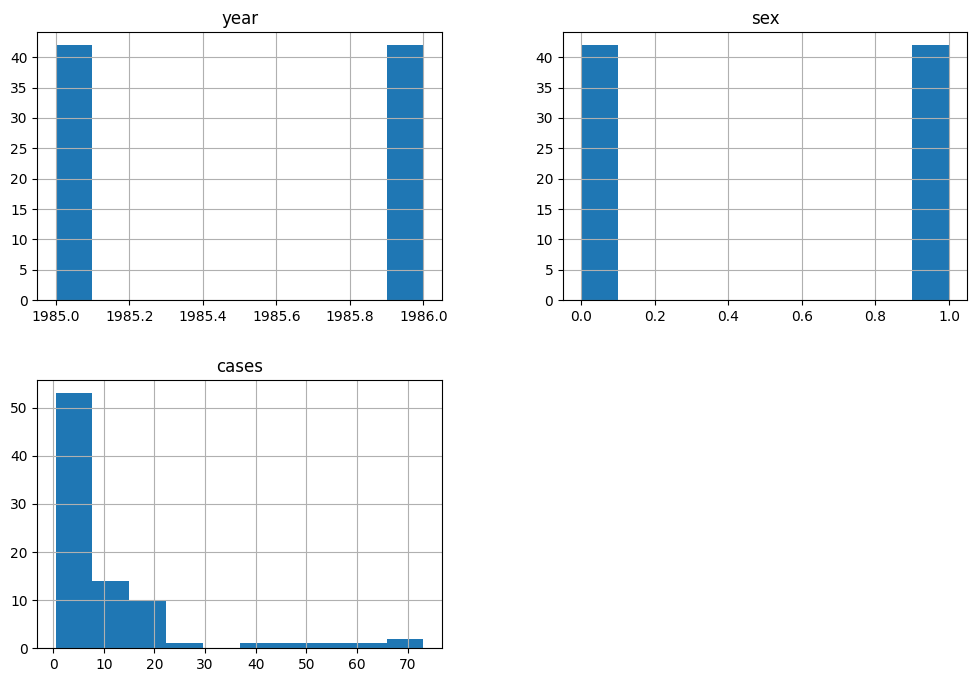

In [63]:
data.hist(figsize=(12,8))
plt.show()


In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['location'] = le.fit_transform(data['location'])
print(data[['location', 'location']].head())

   location  location
0         1         1
1         2         2
2         1         1
3         2         2
4         0         0


In [65]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['cancer_type'] = le.fit_transform(data['cancer_type'])
print(data[['cancer_type', 'cancer_type']].head())

   cancer_type  cancer_type
0            5            5
1            5            5
2            5            5
3            5            5
4            5            5


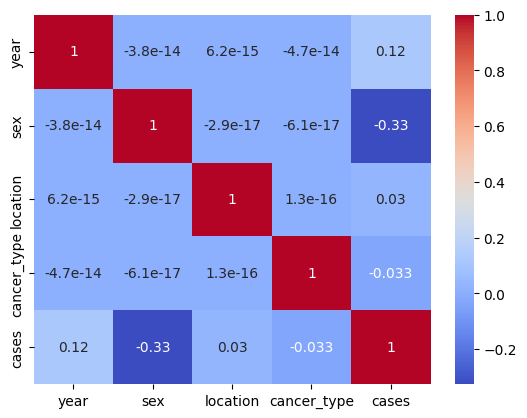

In [66]:
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()


KNN Accuracy: 0.8823529411764706
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        12
           1       1.00      0.60      0.75         5

    accuracy                           0.88        17
   macro avg       0.93      0.80      0.84        17
weighted avg       0.90      0.88      0.87        17



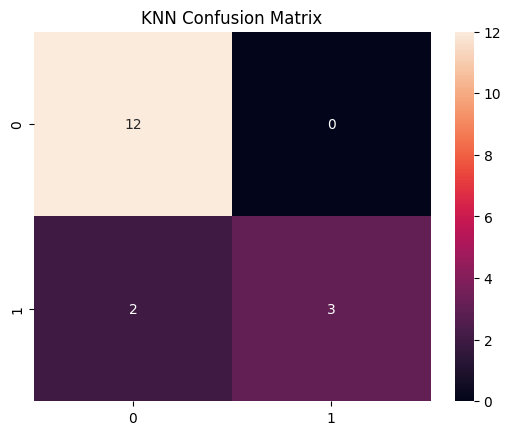

In [67]:
data['cases_class'] = (data['cases'] >= 10).astype(int) 
X = data.drop(['cases', 'cases_class'], axis=1)
y = data['cases_class']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("KNN Confusion Matrix")
plt.show()



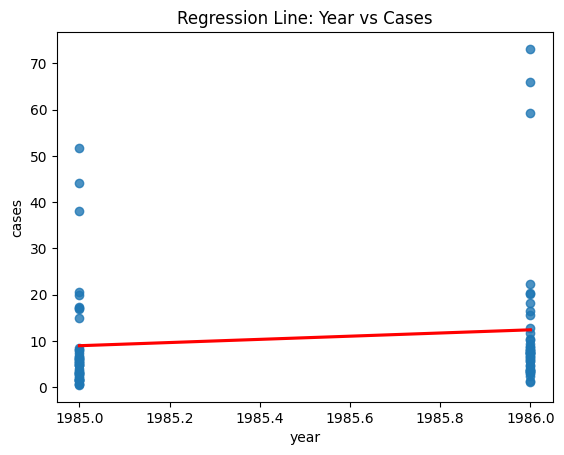

Coefficients: [ 0.0952381  -0.23809524  0.01785714  0.05357143]
Intercept: -188.89285714285703


In [68]:
from sklearn.preprocessing import LabelEncoder
for col in ['sex', 'location', 'cancer_type']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

model = LinearRegression()
model.fit(X, y)


y_pred = model.predict(X)
import seaborn as sns

sns.regplot(x=data['year'], y=data['cases'], ci=None, line_kws={"color":"red"})
plt.title("Regression Line: Year vs Cases")
plt.show()

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)



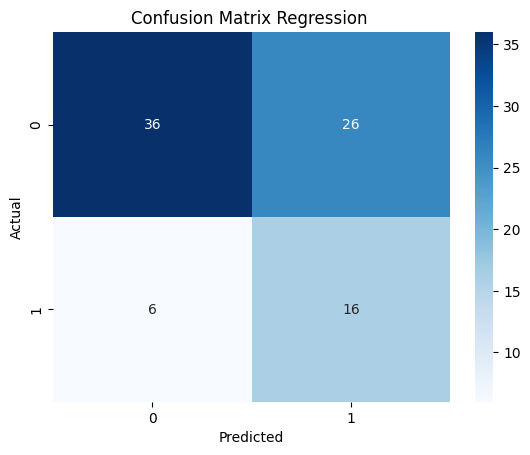

Accuracy: 0.6190476190476191
              precision    recall  f1-score   support

           0       0.86      0.58      0.69        62
           1       0.38      0.73      0.50        22

    accuracy                           0.62        84
   macro avg       0.62      0.65      0.60        84
weighted avg       0.73      0.62      0.64        84



In [69]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
for col in ['sex', 'location', 'cancer_type']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])


X = data[['year', 'sex', 'location', 'cancer_type']]
y = data['cases']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

y_actual_class = (y >= 10).astype(int)  


y_pred_class = (y_pred >= 10).astype(int)

cm = confusion_matrix(y_actual_class, y_pred_class)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Regression ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



accuracy = accuracy_score(y_actual_class, y_pred_class)
print("Accuracy:", accuracy)


print(classification_report(y_actual_class, y_pred_class))

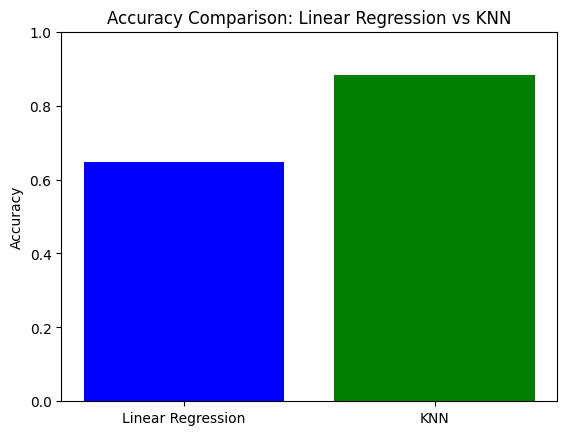

Linear Regression Accuracy: 0.6470588235294118
KNN Accuracy: 0.8823529411764706


In [70]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)
y_pred_lin_class = (y_pred_lin >= 0.5).astype(int)

acc_lin = accuracy_score(y_test, y_pred_lin_class)


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)


accuracy_scores = {"Linear Regression": acc_lin, "KNN": acc_knn}

plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['blue', 'green'])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Linear Regression vs KNN")
plt.ylim(0, 1) 
plt.show()



lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


print("Linear Regression Accuracy:", acc_lin)
print("KNN Accuracy:", acc_knn)

In [71]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

for col in ['sex', 'location', 'cancer_type']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    
sex_encoder = LabelEncoder()
location_encoder = LabelEncoder()
cancer_encoder = LabelEncoder()

data['sex'] = sex_encoder.fit_transform(data['sex'])
data['location'] = location_encoder.fit_transform(data['location'])
data['cancer_type'] = cancer_encoder.fit_transform(data['cancer_type'])

print("Sex classes:", sex_encoder.classes_)
print("Location classes:", location_encoder.classes_)
print("Cancer type classes:", cancer_encoder.classes_)


new_sample = pd.DataFrame({
    'year': [1986],
    'sex': sex_encoder.transform(['0']),
    'location': location_encoder.transform(['2']),
    'cancer_type': cancer_encoder.transform(['5'])
})

knn_pred = knn.predict(new_sample)
print("KNN Prediction (High=1, Low=0):", knn_pred[0])



Sex classes: [0 1]
Location classes: [0 1 2]
Cancer type classes: [0 1 2 3 4 5 6]
KNN Prediction (High=1, Low=0): 1
